In [28]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy
from scipy import odr

import Methods as m
import importlib

importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [29]:
freq = 195
V = 0.0333 # Volts
savename = "10s measurement Mar 18 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 18 measurement/195kHz_10s_0p0333V.csv')


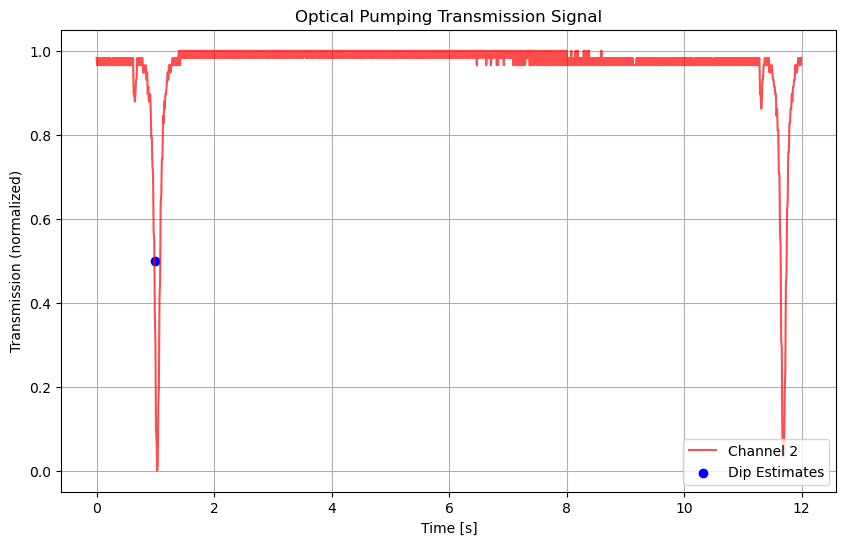

In [30]:
t0 = 0.5
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0 =  1

plt.figure(figsize=(10, 6))
# Plot CH1 and CH2
# plt.plot(df['Sequence'], df['CH1'], label='Channel 1', color='blue', alpha=0.7)
plt.plot(time, y2_norm, label='Channel 2', color='red', alpha=0.7)
plt.scatter(x0, 0.5, label='Dip Estimates', color='blue')
# plt.plot(time,y2_norm, label='Channel 2 normalized', color='red', alpha=0.7)

# Labels and formatting
plt.xlabel('Time [s]')
plt.ylabel('Transmission (normalized)')
plt.title('Optical Pumping Transmission Signal')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("figures/" + savename, dpi=300)

plt.show()

In [31]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h", "g", "x0"]
p0 = (1, 1, 0.3, x0)
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.973499489312564
h 1.0020270634844861
g 0.04441152292803026
x0 0.5309729400796499


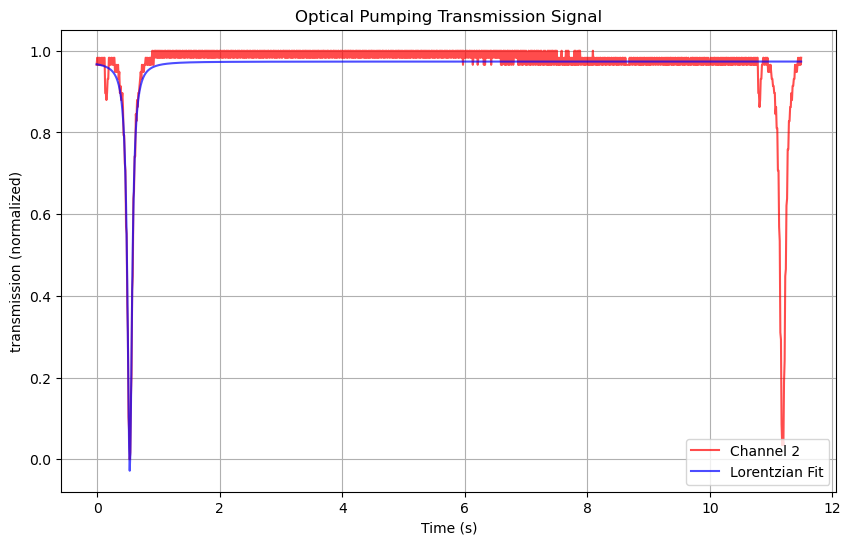

In [32]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)


In [33]:
x0_u = ufloat(popt[3], perr[3]) + t0
dt = time[1] - time[0]
x0_index = int(x0_u.n // dt)

numAvg = 10

v_0 = ufloat(np.mean(y1[x0_index - numAvg : x0_index + numAvg]),
             np.std(y1[x0_index - numAvg : x0_index + numAvg]) / np.sqrt(2*numAvg))

print(f"v_0: {v_0:.2ue}")

v_0: (3.92+/-0.14)e-02


In [34]:

time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 18 measurement/195kHz_10s_0V.csv')


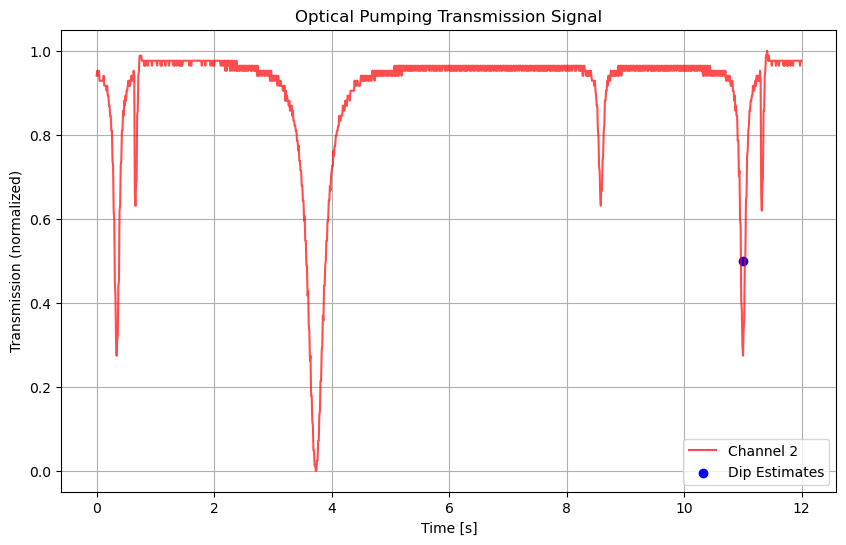

In [35]:
t0 = 10
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0 =  11

plt.figure(figsize=(10, 6))
# Plot CH1 and CH2
# plt.plot(df['Sequence'], df['CH1'], label='Channel 1', color='blue', alpha=0.7)
plt.plot(time, y2_norm, label='Channel 2', color='red', alpha=0.7)
plt.scatter(x0, 0.5, label='Dip Estimates', color='blue')
# plt.plot(time,y2_norm, label='Channel 2 normalized', color='red', alpha=0.7)

# Labels and formatting
plt.xlabel('Time [s]')
plt.ylabel('Transmission (normalized)')
plt.title('Optical Pumping Transmission Signal')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("figures/" + savename, dpi=300)

plt.show()

In [36]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h", "g", "x0"]
p0 = (1, 1, 0.3, x0)
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,15)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9599009114394541
h 0.6773489010594927
g 0.0508672117730361
x0 0.9997394572057194


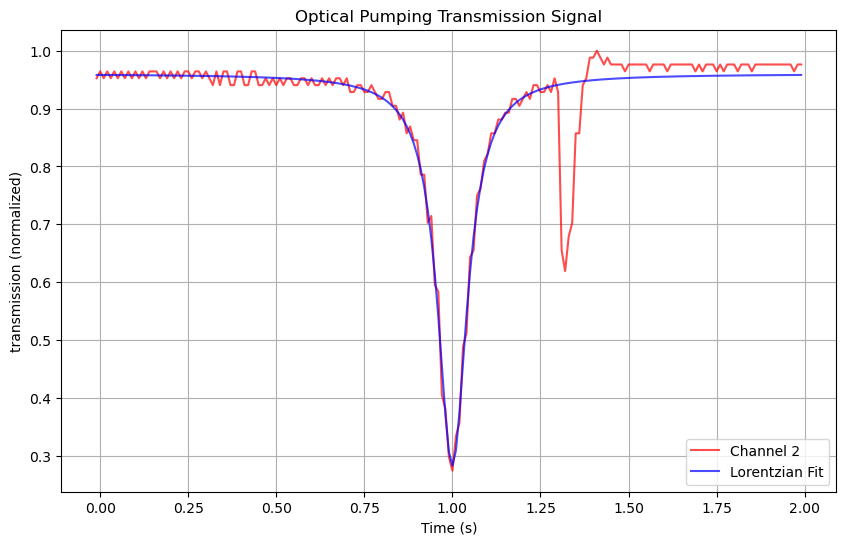

In [37]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)


In [38]:
x1_u = ufloat(popt[3], perr[3]) + t0
dt = time[1] - time[0]
x1_index = int(x1_u.n // dt)

numAvg = 10

v_1 = ufloat(np.mean(y1[x1_index - numAvg : x1_index + numAvg]),
             np.std(y1[x1_index - numAvg : x1_index + numAvg]) / np.sqrt(2*numAvg))

print(f"v_1: {v_1:.2ue}")

v_1: (9.548+/-0.027)e-01


In [43]:
VtoB = ufloat(0.6 * 10**(-4),0.6 * 10**(-4) /100) * 1.03360784475


print(f"VtoB: {VtoB:.2ue}")

deltaB = (v_1 - v_0) * VtoB
print(f"deltaB: {deltaB:.2ue}")

VhoriztoB = deltaB/V
print(f"VhoriztoB: {VhoriztoB:.5ue}")

VtoB: (6.202+/-0.062)e-05
deltaB: (5.678+/-0.060)e-05
VhoriztoB: (1.705174+/-0.017945)e-03
